In [1]:
import sys
from pathlib import Path
import numpy as np
from gears import *
%load_ext autoreload
%autoreload 2


In [2]:
# some definitions
def inv(alpha):
    return np.tan(alpha) - alpha



In [3]:
m = 1.5
x1=0.25#0.539#
nZ1 = 10
rack_data = rackData(m=m, alpha=20.0, prof_shift=0, rc=0.35*m, rho_B=9000.0, rho_F=9000, alpha_F=0, s_F=0.5, cut_rack_tip=1.25)
rack = rackCutter().curved_geometry(rack_data)
gear = Gear(rack, nZ = nZ1, profile_shift=x1, internal_gear=False)
# gear.plot_tooth()

print(f"Gear outer radius: {gear.data.outer_radius}")
print(f"Gear pitch radius: {gear.data.pitch_radius}")

gear.set_lengthwise_curve(lengthwise_curve_function=25)

Ep_tip = 100*m/1.5; Ep_root = 0; Ef_toe = 25*m/1.5; Ef_heel = 25*m/1.5# in microns
facewidth = 20
gear.apply_crowning(Ep_tip, Ep_root, Ef_toe, Ef_heel, facewidth, order_prof = 3, order_face = 2)


gear.fit_nurbs(z_range=(-facewidth*1.1,facewidth*1.1), both_flanks=True, verbose=False, backlash=0.1)



# gear.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = f'step_files\m1dot5_n_{nZ1}_beta25.stp')

print(gear.data.outer_radius)
print(gear.data.form_diameter_radius)
print(gear.data.root_radius)


Gear outer radius: 9.375
Gear pitch radius: 7.5
9.375
7.094921610133338
6.0


In [4]:
m = 1.5
x2=0.0#0.539#
nZ2 = nZ1*2+1
print(f"Driven gear number of teeth: {nZ2}")
rack_data = rackData(m=m, alpha=20.0, prof_shift=0, rc=0.35*m, rho_B=9000.0, rho_F=9000, alpha_F=0, s_F=0.5, cut_rack_tip=1.25)
rack = rackCutter().curved_geometry(rack_data)
gear2 = Gear(rack, nZ = nZ2, profile_shift=x2, internal_gear=False)
# gear.plot_tooth()

print(f"Gear outer radius: {gear2.data.outer_radius}")
print(f"Gear pitch radius: {gear2.data.pitch_radius}")

gear2.set_lengthwise_curve(lengthwise_curve_function=-25)

Ep_tip = 100*m/1.5; Ep_root = 0; Ef_toe = 25*m/1.5; Ef_heel = 25*m/1.5# in microns
facewidth = 20
gear2.apply_crowning(Ep_tip, Ep_root, Ef_toe, Ef_heel, facewidth, order_prof = 3, order_face = 2)


gear2.fit_nurbs(z_range=(-facewidth/2*1.1,facewidth/2*1.1), both_flanks=True, verbose=False, backlash=0.1)
# gear2.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = f'step_files\m1dot5_n_{nZ2}_beta25.stp')


Driven gear number of teeth: 21
Gear outer radius: 17.25
Gear pitch radius: 15.75


In [5]:
alpha = 20.0*np.pi/180
m = 1.5
r1 = m*nZ1/2; r2 = m*nZ2/2
a_nominal = r1+r2
i_alpha_new = inv(alpha) + (x1+x2)*m*np.tan(alpha)/a_nominal

from scipy.optimize import fsolve
f = lambda x: i_alpha_new - np.tan(x) + x
sol = fsolve(f, alpha)
a = a_nominal*np.cos(alpha)/np.cos(sol)
print(f"Nominal shaft distance: {a_nominal}")
print(f"New meshing pressure angle: {sol*180/np.pi}")
print(f"New shaft distance: {a}")

Nominal shaft distance: 23.25
New meshing pressure angle: [22.24994134]
New shaft distance: [23.60549775]


In [6]:
# Given the shaft distance we need to design the 1:1 ratio gears
nZ_II = np.floor(a/m-1/2)
print(f"Num teeth 2nd gear: {nZ_II}")
a_II = m/2*(2*nZ_II+1) # coprime gear numbers
print(a_II)
alpha_new = np.arccos(a_II/a*np.cos(alpha))
print(alpha_new*180/np.pi)
k = (inv(alpha_new) - inv(alpha))*a_II/np.tan(alpha)
print(k)
x1 = k/2/m
x2 = x1
print(x1)
print(x2)

Num teeth 2nd gear: [15.]
[23.25]
[22.24994134]
[0.375]
[0.125]
[0.125]


In [7]:
x = x1[0]
nZ = nZ_II[0]
rack_data = rackData(m=m, alpha=20.0, prof_shift=0, rc=0.35*m, rho_B=9000.0, rho_F=9000, alpha_F=0, s_F=0.5, cut_rack_tip=1.25)
rack = rackCutter().curved_geometry(rack_data)
gear3 = Gear(rack, nZ = nZ, profile_shift=x, internal_gear=False)

gear3.set_lengthwise_curve(lengthwise_curve_function=+25)

Ep_tip = 100*m/1.5; Ep_root = 0; Ef_toe = 25*m/1.5; Ef_heel = 25*m/1.5# in microns
facewidth = 20
gear3.apply_crowning(Ep_tip, Ep_root, Ef_toe, Ef_heel, facewidth, order_prof = 3, order_face = 2)


gear3.fit_nurbs(z_range=(-facewidth/2*1.1,facewidth/2*1.5), both_flanks=True, verbose=False, backlash=0.1)
# gear3.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = f'step_files\m1dot5_n_{nZ}_beta25.stp')

print(nZ)
print(gear3.data.outer_radius)
print(gear3.data.form_diameter_radius)
print(gear3.data.root_radius)


15.0
12.937499999999996
10.572538785669614
9.562499999999996


In [8]:
gear3 = Gear(rack, nZ = nZ+1, profile_shift=x, internal_gear=False)

gear3.set_lengthwise_curve(lengthwise_curve_function=-25)

Ep_tip = 100*m/1.5; Ep_root = 0; Ef_toe = 25*m/1.5; Ef_heel = 25*m/1.5# in microns
facewidth = 20
gear3.apply_crowning(Ep_tip, Ep_root, Ef_toe, Ef_heel, facewidth, order_prof = 3, order_face = 2)


gear3.fit_nurbs(z_range=(-facewidth/2*1.1,facewidth/2*1.5), both_flanks=True, verbose=False, backlash=0.1)
# gear3.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = f'step_files\m1dot5_n_{nZ+1}_beta25.stp')

print(nZ)
print(gear3.data.outer_radius)
print(gear3.data.form_diameter_radius)
print(gear3.data.root_radius)

15.0
13.687499999999996
11.278436032551811
10.312499999999996


<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\egrab\AppData\Local\Temp\ipykernel_51296\2177124398.py:15: SyntaxWarning: invalid escape sequence '\s'
  spline_shaft.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = f'step_files\spline_m1_n_{nZ_spline}.stp')
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


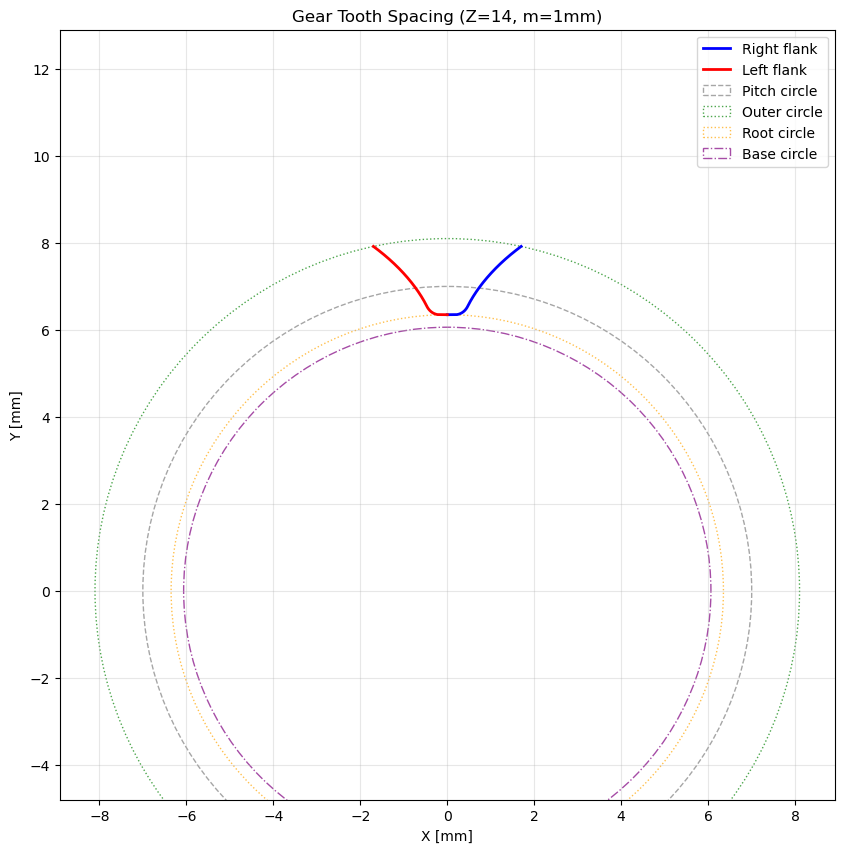

c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1094: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  face_top = topods_Face(filler_top.Shape())
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1101: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  face_toe = topods_Face(filler_toe.Shape())
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1108: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  face_heel = topods_Face(filler_heel.Shape())


Cutter shape is invalid
Blank shape is invalid
8.1


In [9]:
# splines
m = 1
x1 = 0.1
nZ_spline = 14
rack_data = rackData(m=m, alpha=30.0, prof_shift=0, rc=0.30*m, rho_B=9000.0, rho_F=9000, alpha_F=0, s_F=0.5, cut_rack_tip=0.75)
rack = rackCutter().curved_geometry(rack_data)
spline_shaft = Gear(rack, nZ = nZ_spline, profile_shift=x1, internal_gear=False)
spline_shaft.plot_tooth()
spline_shaft.set_lengthwise_curve(lengthwise_curve_function=0)

Ep_tip = 100*m/1.5; Ep_root = 0; Ef_toe = 0*m/1.5; Ef_heel = 0*m/1.5# in microns
facewidth = 30+18+9
spline_shaft.apply_crowning(Ep_tip, Ep_root, Ef_toe, Ef_heel, facewidth, order_prof = 3, order_face = 2)
spline_shaft.fit_nurbs(z_range=(-facewidth/2*1.1,facewidth/2*1.5), both_flanks=True, verbose=False, backlash=0.2)
spline_shaft.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = f'step_files\spline_m1_n_{nZ_spline}.stp')

print(spline_shaft.data.outer_radius)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


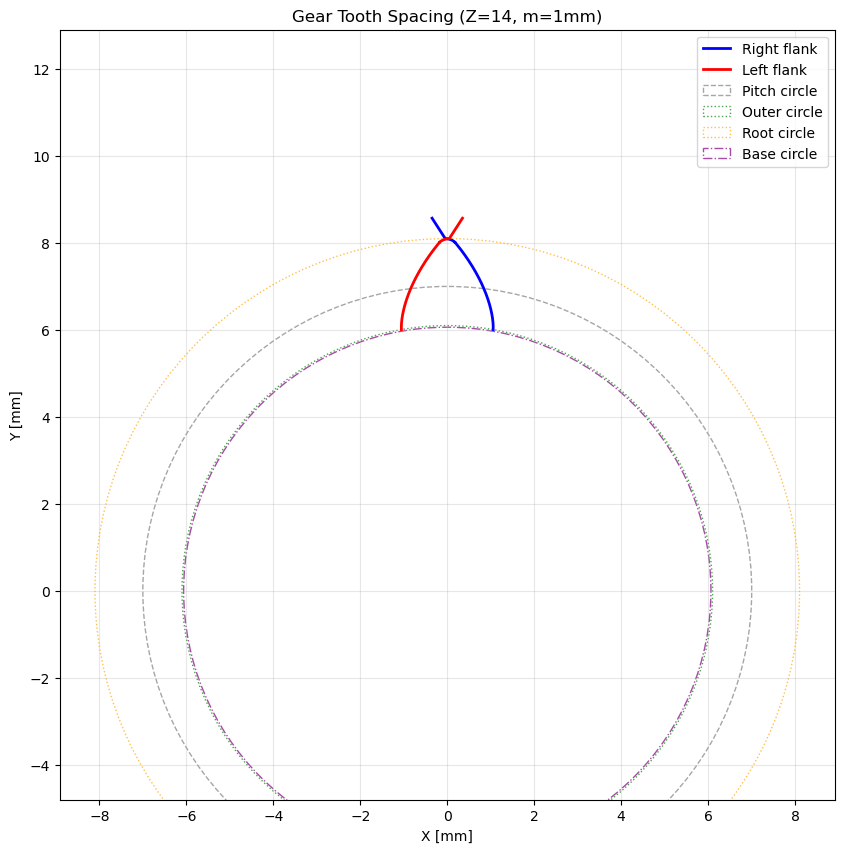

6.1
8.1


In [ ]:
x2 = -0.1
rack_data = rackData(m=m, alpha=30.0, prof_shift=0, rc=0.45*m, rho_B=9000.0, rho_F=9000, alpha_F=0, s_F=0.5, cut_rack_tip=1)
rack = rackCutter().curved_geometry(rack_data)
spline_insert = Gear(rack, nZ = nZ_spline, profile_shift=x2, internal_gear=True)
spline_insert.plot_tooth()
spline_insert.set_lengthwise_curve(lengthwise_curve_function=0)
Ep_tip = 100*m/1.5; Ep_root = 0; Ef_toe = 0*m/1.5; Ef_heel = 0*m/1.5# in microns
facewidth = 15
spline_insert.apply_crowning(Ep_tip, Ep_root, Ef_toe, Ef_heel, facewidth, order_prof = 3, order_face = 2)
spline_insert.fit_nurbs(z_range=(-facewidth/2*1.1,facewidth/2*1.5), both_flanks=True, verbose=False, backlash=0.2)
# spline_insert.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = f'step_files\spline_insert_m1_n_{nZ_spline}.stp')



print(spline_insert.data.outer_radius)
print(spline_insert.data.root_radius)

OIL PUMP RACK GEOMETRY

In [29]:
# 

m = 1.5; alpha = 15; 
rack_data = rackData(m=m, alpha=alpha, prof_shift=0, rc=0.45*m, rho_B=9000.0, rho_F=9000, alpha_F=0, s_F=0.5, cut_rack_tip=1.25)
rack = rackCutter().curved_geometry(rack_data)

rack.apply_facewidth(25, (-10, 10))

rack.fit_nurbs(z_range=(-10,10), both_flanks=True)

rack.generate_CAD(z_range=(-10,10), filename=f'rack_m1dot5_beta_25.stp')


Fitting NURBS surface to rack...
Sampling points...
Generating left flank surface points (vectorized)...
Combining flanks into single continuous surface...
Plotting points to fit
Fitting NURBS to combined tooth surface...
Combined surface - RMS error: 0.000130, Max error: 0.000538


In [28]:

alpha = 15
rack_data = rackData(m=m, alpha=alpha, prof_shift=0, rc=0.45*m, rho_B=9000.0, rho_F=9000, alpha_F=0, s_F=0.5, cut_rack_tip=1.25)
rack = rackCutter().curved_geometry(rack_data)

gear = Gear(rack, nZ = 10, profile_shift=0.5, internal_gear=False)
facewidth = 15
gear.set_lengthwise_curve(lengthwise_curve_function=-25)
gear.fit_nurbs(z_range=(-facewidth/2*1.1,facewidth/2*1.5), both_flanks=True, verbose=False, backlash=0.1)
gear.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = f'step_files\m1dot5_n_{10}_fw15.stp')

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\egrab\AppData\Local\Temp\ipykernel_54488\1899139001.py:9: SyntaxWarning: invalid escape sequence '\m'
  gear.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = f'step_files\m1dot5_n_{10}_fw15.stp')


Cutter shape is invalid
Blank shape is invalid


c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1259: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  face_top = topods_Face(filler_top.Shape())
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1266: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  face_toe = topods_Face(filler_toe.Shape())
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1273: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  face_heel = topods_Face(filler_heel.Shape())


In [27]:
print(f"Gear outerdia: {gear.data.outer_radius}")
print(f"Gear pitch dia: {gear.data.pitch_radius}")
print(f"angle for max stroke travel")

Gear outerdia: 9.75
Gear pitch dia: 7.5
angle for max stroke travel


In [25]:

alpha = 20
rack_data = rackData(m=m, alpha=alpha, prof_shift=0, rc=0.45*m, rho_B=9000.0, rho_F=9000, alpha_F=0, s_F=0.5, cut_rack_tip=1.25)
rack = rackCutter().curved_geometry(rack_data)

gear2 = Gear(rack, nZ = 19, profile_shift=-0.250, internal_gear=False)
facewidth = 10
gear2.set_lengthwise_curve(lengthwise_curve_function=+25)
gear2.fit_nurbs(z_range=(-facewidth/2*1.1,facewidth/2*1.5), both_flanks=True, verbose=False, backlash=0.05)
gear2.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = f'step_files\m1dot5_n_{19}_beta25_oil_pump.stp')
print(f"Gear outerdia: {gear2.data.outer_radius}")
print(f"Gear pitch dia: {gear2.data.pitch_radius}")


<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\egrab\AppData\Local\Temp\ipykernel_54488\2069525965.py:9: SyntaxWarning: invalid escape sequence '\m'
  gear2.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = f'step_files\m1dot5_n_{19}_beta25_oil_pump.stp')
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\utilities.py:124: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  radius = float(np.sqrt(point[0]**2 + point[1]**2))


Cutter shape is invalid
Blank shape is invalid
Gear outerdia: 15.375
Gear pitch dia: 14.25


c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1259: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  face_top = topods_Face(filler_top.Shape())
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1266: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  face_toe = topods_Face(filler_toe.Shape())
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1273: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  face_heel = topods_Face(filler_heel.Shape())


PERISTALTIC PUMP PLANETARY GEARS

In [30]:
#some transmission ratio calculation
m = 1.0; alpha = 20

z1 = 15
z2 = 18
z3 = 51


In [31]:
rack_data = rackData(m=m, alpha=alpha, prof_shift=0, rc=0.40*m, rho_B=9000.0, rho_F=9000, alpha_F=0, s_F=0.5, cut_rack_tip=1.25)
rack = rackCutter().curved_geometry(rack_data)


crown = Gear(rack, nZ = z3, profile_shift=-0.0, internal_gear=True)
facewidth = 10
crown.set_lengthwise_curve(lengthwise_curve_function=+25)
crown.fit_nurbs(z_range=(-facewidth/2*1.1,facewidth/2*1.1), both_flanks=True, verbose=False, backlash=0.05)
crown.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = rf'C:\Users\egrab\Desktop\Unipi2024\RTDA\NUovo_pignone\CAD\pompa_olio_mkII_peristaltica\m1_n_{z3}_beta25_oil_pump.stp')
print(f"Gear outerdia: {crown.data.outer_radius}")
print(f"Gear pitch dia: {crown.data.pitch_radius}")

c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\utilities.py:124: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  radius = float(np.sqrt(point[0]**2 + point[1]**2))


Cutter shape is invalid
Blank shape is invalid
Gear outerdia: 24.5
Gear pitch dia: 25.5


c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1261: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1268: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1275: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  


In [32]:
rack_data = rackData(m=m, alpha=alpha, prof_shift=0, rc=0.40*m, rho_B=9000.0, rho_F=9000, alpha_F=0, s_F=0.5, cut_rack_tip=1.25)
rack = rackCutter().curved_geometry(rack_data)


crown = Gear(rack, nZ = z2, profile_shift=-0.0, internal_gear=False)
facewidth = 10
crown.set_lengthwise_curve(lengthwise_curve_function=+25)
crown.fit_nurbs(z_range=(-facewidth/2*1.1,facewidth/2*1.1), both_flanks=True, verbose=False, backlash=0.05)
crown.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = rf'C:\Users\egrab\Desktop\Unipi2024\RTDA\NUovo_pignone\CAD\pompa_olio_mkII_peristaltica\m1_n_{z2}_beta25_oil_pump.stp')
print(f"Gear outerdia: {crown.data.outer_radius}")
print(f"Gear pitch dia: {crown.data.pitch_radius}")

c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\utilities.py:124: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  radius = float(np.sqrt(point[0]**2 + point[1]**2))


Cutter shape is invalid
Blank shape is invalid
Gear outerdia: 10.0
Gear pitch dia: 9.0


c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1261: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1268: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1275: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  


In [33]:
rack_data = rackData(m=m, alpha=alpha, prof_shift=0, rc=0.40*m, rho_B=9000.0, rho_F=9000, alpha_F=0, s_F=0.5, cut_rack_tip=1.25)
rack = rackCutter().curved_geometry(rack_data)


crown = Gear(rack, nZ = z1, profile_shift=-0.0, internal_gear=False)
facewidth = 10
crown.set_lengthwise_curve(lengthwise_curve_function=-25)
crown.fit_nurbs(z_range=(-facewidth/2*1.1,facewidth/2*1.1), both_flanks=True, verbose=False, backlash=0.05)
crown.generate_gear_CAD(z_range=(-facewidth/2,facewidth/2), rim_thickness=2.0, filename = rf'C:\Users\egrab\Desktop\Unipi2024\RTDA\NUovo_pignone\CAD\pompa_olio_mkII_peristaltica\m1_n_{z1}_beta25_oil_pump_SUN.stp')
print(f"Gear outerdia: {crown.data.outer_radius}")
print(f"Gear pitch dia: {crown.data.pitch_radius}")



c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\utilities.py:124: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  radius = float(np.sqrt(point[0]**2 + point[1]**2))


Cutter shape is invalid
Blank shape is invalid
Gear outerdia: 8.5
Gear pitch dia: 7.5


c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1261: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1268: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  
c:\Users\egrab\Desktop\Repositories\SpyGO\gears\main\core.py:1275: DeprecationWarning: Call to deprecated function topods_Face since pythonocc-core 7.7.1. This function will be removed in a future release, please rather use the static method topods.Face
  
